In [ ]:
# 패키지
import os
import time
import torch
from torch import nn
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
!pip install torchinfo
from torchinfo import summary
import torch.optim as optim
import torchvision

In [ ]:
# 학습에 사용할 CPU나 GPU, MPS 장치를 얻습니다.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [ ]:
# 데이터셋 로드

# transform
transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])

# 공개 데이터셋에서 train 데이터를 내려받습니다.
train_part = datasets.Flowers102(
    root="data",
    split="train",
    download=True,
    transform=transform,
)

# 공개 데이터셋에서 validation 데이터를 내려받습니다.
val_part = datasets.Flowers102(
    root="data",
    split="val",
    download=True,
    transform=transform,
)

# 공개 데이터셋에서 test 데이터를 내려받습니다.
test_data = datasets.Flowers102(
    root="data",
    split="test",
    download=True,
    transform=transform,
)

training_data = ConcatDataset([train_part, val_part])

batch_size = 64

# 데이터로더를 생성합니다.
train_dataloader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True,
    # drop_last=True
    )
test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    # drop_last=True
    )

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

100%|██████████| 345M/345M [00:17<00:00, 19.4MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.79MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 10.2MB/s]


Shape of X [N, C, H, W]: torch.Size([64, 3, 128, 128])
Shape of y: torch.Size([64]) torch.int64


In [ ]:
# baseline 코드
# 모델을 정의합니다.
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
# VGG16 실험

# VGG 모델 자체를 생성하는 클래스입니다.
class VGG(nn.Module):
    def __init__(self, num_cnn_list=[2, 2, 3, 3, 3], channel_list=[64, 128, 256, 512, 512], num_classes=10):
        super(VGG, self).__init__()
        assert len(num_cnn_list) == len(channel_list), "num_cnn_list와 channel_list의 길이가 일치해야 합니다."

        layers = []
        in_channels = 3

        for num_cnn, out_channels in zip(num_cnn_list, channel_list):
            layers.append(self._make_vgg_block(in_channels, out_channels, num_cnn))
            in_channels = out_channels  # 다음 블록의 입력 채널을 설정

        self.feature_extractor = nn.Sequential(*layers)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))  # 224, 224 대상으로 최종 512x7x7이 되는데 flower102로 바꾸면서 최종출력이 512x4x4로 차원 안맞아서 GAP추가해서 1x1로 고정시킴

        final_channels = channel_list[-1]
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(final_channels * 1 * 1, 4096), # 👈 고정이 아닌 동적 변수 적용
            nn.ReLU(True),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Linear(4096, num_classes)
        )

    def _make_vgg_block(self, in_channels, out_channels, num_cnn):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), nn.ReLU(True)]
        for _ in range(num_cnn - 1):
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU(True))
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))  # Max Pooling 추가
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x


⚡ 현재 실험 진행 중 모드: BASELINE
Epoch [1/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [2/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [3/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [4/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [5/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [6/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [7/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [8/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [9/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [10/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [11/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [12/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [13/20] -> Train Loss: 4.6251 | Val Acc: 0.42% | Total Errors: 6123개
Epoch [

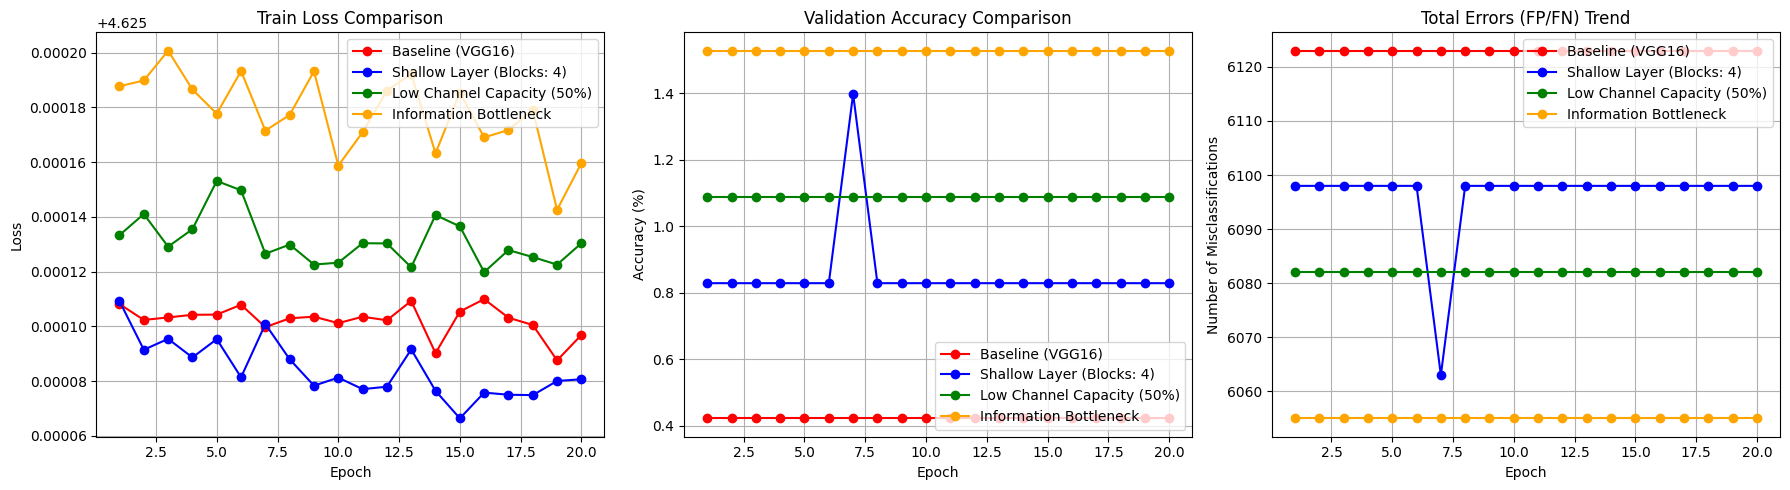

In [ ]:
# VGG 학습

BATCH_SIZE = 64
EPOCH = 20
NUM_CLASSES = 102

# ablation study model config
MODEL_PARAMS = {
        'baseline':             {"num_cnn_list": [2, 2, 3, 3, 3],  "channel_list": [64, 128, 256, 512, 512]},
        'shallow_layer':        {"num_cnn_list": [1, 1, 2, 2],     "channel_list": [64,128,256,512]},
        'low_channel_capacity': {"num_cnn_list": [2, 2, 3, 3, 3],  "channel_list": [32, 64, 128, 256, 256]},
        'bottleneck':           {"num_cnn_list": [2, 2, 3, 3, 3],  "channel_list": [64, 128, 256, 512, 128]},
}

all_results = {}
criterion = nn.CrossEntropyLoss()
total_start_time = time.time()

for mode, config in MODEL_PARAMS.items():
    print(f"\n==================================================")
    print(f"⚡ 현재 실험 진행 중 모드: {mode.upper()}")
    print(f"==================================================")

    # 매 실험마다 지정된 가설(설계 변수)에 따라 새로운 인스턴스 빌드
    model = VGG(
        num_cnn_list=config["num_cnn_list"],
        channel_list=config["channel_list"],
        num_classes=NUM_CLASSES
    ).to(device)

    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

    # 기록용 딕셔너리 초기화
    history = {
        'train_loss': [],
        'val_accuracy': [],
        'val_errors': []
    }

    for epoch in range(EPOCH):
        # ----------------------------------------
        #               TRAIN STEP
        # ----------------------------------------
        model.train()
        running_loss = 0.0
        train_total = 0

        for i, (inputs, labels) in enumerate(train_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            train_total += inputs.size(0)

        epoch_train_loss = running_loss / train_total
        history['train_loss'].append(epoch_train_loss)

        # ----------------------------------------
        #             VALIDATION STEP
        # ----------------------------------------
        model.eval()
        val_correct = 0
        val_total = 0
        total_errors = 0  # FP 및 FN 경향성(총 에러 개수) 추적용

        with torch.no_grad():
            for inputs, labels in test_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)

                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                # 오탐(FP/FN) 마스크 연산 누적
                incorrect_mask = (predicted != labels)
                total_errors += incorrect_mask.sum().item()

        epoch_val_acc = 100 * val_correct / val_total
        history['val_accuracy'].append(epoch_val_acc)
        history['val_errors'].append(total_errors)

        print(f"Epoch [{epoch+1}/{EPOCH}] -> Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% | Total Errors: {total_errors}개")

    all_results[mode] = history

print(f"\n🎉 전체 실험 종료! 총 소요 시간: {time.time() - total_start_time:.2f}초")


# ----------------------------------------------------
# 3. 3분할 통합 결과 시각화 (Ablation Plot)
# ----------------------------------------------------
epochs_range = range(1, EPOCH + 1)
colors = {'baseline': 'r', 'shallow_layer': 'b', 'low_channel_capacity': 'g', 'bottleneck': 'orange'}
labels = {
    'baseline': 'Baseline (VGG16)',
    'shallow_layer': 'Shallow Layer (Blocks: 4)',
    'low_channel_capacity': 'Low Channel Capacity (50%)',
    'bottleneck': 'Information Bottleneck'
}

plt.figure(figsize=(18, 5))

# 그래프 1: Train Loss
plt.subplot(1, 3, 1)
for mode in MODEL_PARAMS.keys():
    plt.plot(epochs_range, all_results[mode]['train_loss'], colors[mode], label=labels[mode], marker='o')
plt.title('Train Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 그래프 2: Validation Accuracy
plt.subplot(1, 3, 2)
for mode in MODEL_PARAMS.keys():
    plt.plot(epochs_range, all_results[mode]['val_accuracy'], colors[mode], label=labels[mode], marker='o')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(True)

# 그래프 3: 오탐(Prediction Errors) 추이 비교
plt.subplot(1, 3, 3)
for mode in MODEL_PARAMS.keys():
    plt.plot(epochs_range, all_results[mode]['val_errors'], colors[mode], label=labels[mode], marker='o')
    plt.title('Total Errors (FP/FN) Trend')
plt.xlabel('Epoch')
plt.ylabel('Number of Misclassifications')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
# ResNet34 실험

# resnet

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, use_shortcut=True):
        '''
            inplanes: 입력 특징 맵의 차원 수
            planes: 출력 특징 맵의 차원 수
            stride: sliding window 이동 간격
            use_shortcut: shortcut 사용 여부. False면 forward에서 shortcut 합연산 사용하지 않게됨

            예시: 100x100 RGB 이미지를 입력으로 가정 -> inplanes = 100x100x3
            출력 특징맵 크기가 100x100 채널수 8개로 만들고 싶다 -> planes = 100x100x8

            100x100x3 -> 1 conv layer | 100 x 100 x8 -> 2 conv layer
        '''
        super().__init__()
        self.use_shortcut = use_shortcut
        self.conv1 = nn.Conv2d(
            inplanes,
            planes,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)

        # 만약 stride가 1이 아니거나 입력 특징맵 차원이 최종 출력 특징 차원과 다를 경우 -> 이전 레이어 특징을 출력에 합연산해야하는데 차원 수가 다르면 안되기 때문에 이를 위한 방어 코드임
        # 방어 방법은 입력 차원 수를 설정된 값에 따라 만들어졌을 출력차원에 맞춰서 변형한 값을 넘기는 것임
        if stride != 1 or inplanes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    inplanes,
                    self.expansion * planes,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(self.expansion * planes)
            )
        else:
            self.shortcut = nn.Sequential()

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.use_shortcut:
            out += self.shortcut(x)
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000, use_shortcut=True):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.inplanes = 64
        # 초기 입력값을 7x7 conv를 통해 특징 맵으로 만드는 단계
        self.stem = nn.Sequential(
            nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(self.inplanes),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Residual Block(or Bottleneck Residual Block) 레이어
        self.stage1 = self._make_layer(block, 64, layers[0], stride=1)
        self.stage2 = self._make_layer(block, 128, layers[1], stride=2)
        self.stage3 = self._make_layer(block, 256, layers[2], stride=2)
        self.stage4 = self._make_layer(block, 512, layers[3], stride=2)

        # 특징 맵 추출 완료 후 풀링 레이어
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # 최종 classfication 수행 레이어. 입력이 최종 스테이지 출력과 동일해야 함
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        layers = []
        layers.append(block(self.inplanes, planes, stride, self.use_shortcut))
        self.inplanes = planes * block.expansion
        for _ in range(num_blocks - 1):
            layers.append(block(self.inplanes, planes, 1, self.use_shortcut))

        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.stem(x)
        out = self.stage1(out)
        out = self.stage2(out)
        out = self.stage3(out)
        out = self.stage4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

# resnet34 = ResNet(BasicBlock, [3, 4, 6, 3], 1000)
resnet34 = ResNet(BasicBlock, [3, 4, 6, 3], num_classes=102)
plain34 = ResNet(BasicBlock, [3, 4, 6, 3], num_classes=102, use_shortcut=False)

In [ ]:
!pip install torchinfo
from torchinfo import summary

summary(resnet34, (1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 102]                  --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-5                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│

In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. 데이터 로드 세팅 (제공해주신 코드 반영)
# ----------------------------------------------------
base_path = os.path.join(os.getcwd(), '..', '..', 'work')
data_path = os.path.join(base_path, 'data')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root=data_path, train=False, download=True, transform=transform)

# 기존에 256이었던 배치 사이즈를 데이터 로더 기준(32)으로 자동 연동합니다.
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

EPOCH = 20
num_classes = 10  # CIFAR-10 클래스 수

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ----------------------------------------------------
# 2. Plain Net 학습 (use_shortcut=False)
# ----------------------------------------------------
print("\n" + "="*50)
print("▶ Start Training: Plain Net (No Shortcut)")
print("="*50)

plain_net = ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, use_shortcut=False)
plain_net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_plain = optim.SGD(plain_net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

plain_train_losses = []
plain_val_accuracy = []

start_time = time.time()

for epoch in range(EPOCH):
    plain_net.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_plain.zero_grad()
        outputs = plain_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_plain.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 배치 사이즈가 32로 작아졌으므로, 300 배치마다 출력하도록 주기를 조정했습니다.
        if i % 300 == 299:
            print(f"[Epoch {epoch + 1}, Batch {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    train_loss = running_loss / len(trainloader)
    plain_train_losses.append(train_loss)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: Plain Net Train Accuracy: {train_acc:.2f}%")

    # 검증 단계
    plain_net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = plain_net(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    plain_val_accuracy.append(val_acc)
    print(f"Epoch {epoch + 1}: Plain Net Validation Accuracy: {val_acc:.2f}%\n")

plain_time = time.time() - start_time
print(f"Plain Net Training Finished. Time taken: {plain_time:.2f}s")


# ----------------------------------------------------
# 3. ResNet 학습 (use_shortcut=True)
# ----------------------------------------------------
print("\n" + "="*50)
print("▶ Start Training: ResNet (With Shortcut)")
print("="*50)

resnet = ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, use_shortcut=True)
resnet.to(device)

optimizer_resnet = optim.SGD(resnet.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

resnet_train_losses = []
resnet_val_accuracy = []

start_time = time.time()

for epoch in range(EPOCH):
    resnet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 300 == 299:
            print(f"[Epoch {epoch + 1}, Batch {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    train_loss = running_loss / len(trainloader)
    resnet_train_losses.append(train_loss)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: ResNet Train Accuracy: {train_acc:.2f}%")

    # 검증 단계
    resnet.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    resnet_val_accuracy.append(val_acc)
    print(f"Epoch {epoch + 1}: ResNet Validation Accuracy: {val_acc:.2f}%\n")

resnet_time = time.time() - start_time
print(f"ResNet Training Finished. Time taken: {resnet_time:.2f}s")


# ----------------------------------------------------
# 4. 결과 시각화
# ----------------------------------------------------
epochs_range = range(1, EPOCH + 1)

# Loss 비교 그래프
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, plain_train_losses, 'r--', label="Plain Net Training Loss")
plt.plot(epochs_range, resnet_train_losses, 'b-', label="ResNet Training Loss")
plt.title('Model Training Loss (Ablation Study)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Accuracy 비교 그래프
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, plain_val_accuracy, 'r--', label="Plain Net Validation Accuracy")
plt.plot(epochs_range, resnet_val_accuracy, 'b-', label="ResNet Validation Accuracy")
plt.title('Model Validation Accuracy (Ablation Study)')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
import time
import torch.optim as optim
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. 데이터 로드 세팅 (제공해주신 코드 반영)
# ----------------------------------------------------

EPOCH = 20
num_classes = 102  # Flowers102 클래스 수


# ----------------------------------------------------
# 2. Plain Net 학습 (use_shortcut=False)
# ----------------------------------------------------
print("\n" + "="*50)
print("▶ Start Training: Plain Net (No Shortcut)")
print("="*50)

plain_net = ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, use_shortcut=False)
plain_net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_plain = optim.SGD(plain_net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

plain_train_losses = []
plain_val_accuracy = []

start_time = time.time()

for epoch in range(EPOCH):
    plain_net.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(train_dataloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_plain.zero_grad()
        outputs = plain_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_plain.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 배치 사이즈가 32로 작아졌으므로, 300 배치마다 출력하도록 주기를 조정했습니다.
        if i % 300 == 299:
            print(f"[Epoch {epoch + 1}, Batch {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    train_loss = running_loss / len(train_dataloader)
    plain_train_losses.append(train_loss)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: Plain Net Train Accuracy: {train_acc:.2f}%")

    # 검증 단계
    plain_net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = plain_net(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    plain_val_accuracy.append(val_acc)
    print(f"Epoch {epoch + 1}: Plain Net Validation Accuracy: {val_acc:.2f}%\n")

plain_time = time.time() - start_time
print(f"Plain Net Training Finished. Time taken: {plain_time:.2f}s")


# ----------------------------------------------------
# 3. ResNet 학습 (use_shortcut=True)
# ----------------------------------------------------
print("\n" + "="*50)
print("▶ Start Training: ResNet (With Shortcut)")
print("="*50)

resnet = ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, use_shortcut=True)
resnet.to(device)

optimizer_resnet = optim.SGD(resnet.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

resnet_train_losses = []
resnet_val_accuracy = []

start_time = time.time()

for epoch in range(EPOCH):
    resnet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(train_dataloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 300 == 299:
            print(f"[Epoch {epoch + 1}, Batch {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    train_loss = running_loss / len(train_dataloader)
    resnet_train_losses.append(train_loss)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: ResNet Train Accuracy: {train_acc:.2f}%")

    # 검증 단계
    resnet.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    resnet_val_accuracy.append(val_acc)
    print(f"Epoch {epoch + 1}: ResNet Validation Accuracy: {val_acc:.2f}%\n")

resnet_time = time.time() - start_time
print(f"ResNet Training Finished. Time taken: {resnet_time:.2f}s")


# ----------------------------------------------------
# 4. 결과 시각화
# ----------------------------------------------------
epochs_range = range(1, EPOCH + 1)

# Loss 비교 그래프
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, plain_train_losses, 'r--', label="Plain Net Training Loss")
plt.plot(epochs_range, resnet_train_losses, 'b-', label="ResNet Training Loss")
plt.title('Model Training Loss (Ablation Study)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Accuracy 비교 그래프
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, plain_val_accuracy, 'r--', label="Plain Net Validation Accuracy")
plt.plot(epochs_range, resnet_val_accuracy, 'b-', label="ResNet Validation Accuracy")
plt.title('Model Validation Accuracy (Ablation Study)')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# 실험2: 레이어 깊이 빼기 (깊은 ResNet34 vs 얕은 ResNet18급)
print("▶ 실험2: Shallow ResNet ([2,2,2,2])")
print("="*50)

shallow_net = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes, use_shortcut=True)
shallow_net.to(device)

optimizer_shallow = optim.SGD(shallow_net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

shallow_train_losses = []
shallow_val_accuracy = []

start_time = time.time()

for epoch in range(EPOCH):
    shallow_net.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_shallow.zero_grad()
        outputs = shallow_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_shallow.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataloader)
    shallow_train_losses.append(train_loss)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}: Shallow Train Acc: {train_acc:.2f}%")

    shallow_net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = shallow_net(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    shallow_val_accuracy.append(val_acc)
    print(f"Epoch {epoch+1}: Shallow Val Acc: {val_acc:.2f}%\n")

print(f"Finished. Time: {time.time()-start_time:.2f}s")

# 실험3: 레이어 깊이 추가 (Deep ResNet [3,4,12,3])
print("="*50)
print("▶ 실험2-b: Deep ResNet ([3,4,12,3])")
print("="*50)

deep_net = ResNet(BasicBlock, [3, 4, 12, 3], num_classes=num_classes, use_shortcut=True)
deep_net.to(device)

optimizer_deep = optim.SGD(deep_net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

deep_train_losses = []
deep_val_accuracy = []

start_time = time.time()

for epoch in range(EPOCH):
    deep_net.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_deep.zero_grad()
        outputs = deep_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_deep.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataloader)
    deep_train_losses.append(train_loss)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}: Deep Train Acc: {train_acc:.2f}%")

    deep_net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = deep_net(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    deep_val_accuracy.append(val_acc)
    print(f"Epoch {epoch+1}: Deep Val Acc: {val_acc:.2f}%\n")

print(f"Finished. Time: {time.time()-start_time:.2f}s")

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCH + 1)

plt.figure(figsize=(10, 6))

# skip 유무
plt.plot(epochs_range, plain_val_accuracy, 'r--', label="Plain (no skip)")
plt.plot(epochs_range, resnet_val_accuracy, 'b-', label="ResNet34 [3,4,6,3]")

# 깊이 실험
plt.plot(epochs_range, shallow_val_accuracy, 'g-', label="Shallow [2,2,2,2]")
plt.plot(epochs_range, deep_val_accuracy, 'm-', label="Deep [3,4,12,3]")

plt.title('Ablation Study - Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()